In [31]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

full_dataset = pd.read_csv(
    "../data/processed/full_dataset.csv",
    parse_dates=["GAME_DATE"]
)

In [2]:
model_dataset = full_dataset.dropna().copy()

print(model_dataset.shape)

(22000, 75)


In [3]:
model_dataset.to_csv(
    "../data/processed/model_dataset.csv",
    index=False
)

model_dataset = pd.read_csv(
    "../data/processed/model_dataset_v2.csv",
    parse_dates=["GAME_DATE"]
)

print(model_dataset.shape)
model_dataset.head()

(22000, 75)


,SEASON_ID,Player_ID,Game_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,FGA,FG_PCT,...,FG3A_SEASON_AVG,FG3A_STD_LAST_5,FG3A_STD_LAST_10,FTA_LAST_GAME,FTA_LAST_5_AVG,FTA_LAST_10_AVG,FTA_SEASON_AVG,FTA_STD_LAST_5,FTA_STD_LAST_10,PLAYER_NAME
0,22025,1630173,22500197,2025-11-09,SAC vs. MIN,L,29,5,7,0.714,...,1.00,1.414214,1.414214,3.0,1.5,1.500000,1.500000,2.121320,2.121320,Precious Achiuwa
1,22025,1630173,22500212,2025-11-11,SAC vs. DEN,L,18,3,5,0.600,...,1.00,1.000000,1.000000,3.0,2.0,2.000000,2.000000,1.732051,1.732051,Precious Achiuwa
2,22025,1630173,22500223,2025-11-12,SAC vs. ATL,L,20,4,6,0.667,...,1.25,0.957427,0.957427,0.0,1.5,1.500000,1.500000,1.732051,1.732051,Precious Achiuwa
3,22025,1630173,22500044,2025-11-14,SAC @ MIN,L,20,2,4,0.500,...,1.00,1.000000,1.000000,4.0,2.0,2.000000,2.000000,1.870829,1.870829,Precious Achiuwa
4,22025,1630173,22500234,2025-11-16,SAC @ SAS,L,5,0,2,0.000,...,1.00,0.836660,0.894427,1.0,2.2,1.833333,1.833333,1.643168,1.722401,Precious Achiuwa


In [4]:
target = "REB"

features = [
    "IS_HOME",
    "REST_DAYS",
    "GAMES_PLAYED",

    "PTS_LAST_GAME",
    "PTS_LAST_5_AVG",
    "PTS_LAST_10_AVG",
    "PTS_SEASON_AVG",
    "PTS_STD_LAST_5",
    "PTS_STD_LAST_10",

    "REB_LAST_GAME",
    "REB_LAST_5_AVG",
    "REB_LAST_10_AVG",
    "REB_SEASON_AVG",
    "REB_STD_LAST_5",
    "REB_STD_LAST_10",

    "AST_LAST_GAME",
    "AST_LAST_5_AVG",
    "AST_LAST_10_AVG",
    "AST_SEASON_AVG",
    "AST_STD_LAST_5",
    "AST_STD_LAST_10",

    "MIN_LAST_GAME",
    "MIN_LAST_5_AVG",
    "MIN_LAST_10_AVG",
    "MIN_SEASON_AVG",
    "MIN_STD_LAST_5",
    "MIN_STD_LAST_10",

    "FGA_LAST_GAME",
    "FGA_LAST_5_AVG",
    "FGA_LAST_10_AVG",
    "FGA_SEASON_AVG",
    "FGA_STD_LAST_5",
    "FGA_STD_LAST_10",

    "FG3A_LAST_GAME",
    "FG3A_LAST_5_AVG",
    "FG3A_LAST_10_AVG",
    "FG3A_SEASON_AVG",
    "FG3A_STD_LAST_5",
    "FG3A_STD_LAST_10",

    "FTA_LAST_GAME",
    "FTA_LAST_5_AVG",
    "FTA_LAST_10_AVG",
    "FTA_SEASON_AVG",
    "FTA_STD_LAST_5",
    "FTA_STD_LAST_10",
]

Linear Regression Testing

In [5]:
model_dataset = model_dataset.sort_values("GAME_DATE").reset_index(drop=True)

split_index = int(len(model_dataset) * 0.8)

train = model_dataset.iloc[:split_index].copy()
test = model_dataset.iloc[split_index:].copy()

In [6]:
X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

In [7]:
print("Training rows:", len(train))
print("Testing rows:", len(test))

print("\nTraining date range:")
print(train["GAME_DATE"].min(), "to", train["GAME_DATE"].max())

print("\nTesting date range:")
print(test["GAME_DATE"].min(), "to", test["GAME_DATE"].max())

print("\nFeature shapes:")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

Training rows: 17600
Testing rows: 4400

Training date range:
2025-10-24 00:00:00 to 2026-03-11 00:00:00

Testing date range:
2026-03-11 00:00:00 to 2026-04-12 00:00:00

Feature shapes:
X_train: (17600, 45)
X_test: (4400, 45)


In [8]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)

In [9]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_rmse = mean_squared_error(
    y_test,
    linear_predictions
) ** 0.5
linear_r2 = r2_score(y_test, linear_predictions)

print("Linear Regression Results")
print(f"MAE: {linear_mae:.2f}")
print(f"RMSE: {linear_rmse:.2f}")
print(f"R²: {linear_r2:.3f}")

Linear Regression Results
MAE: 1.90
RMSE: 2.50
R²: 0.438


Random Forest Testing

In [10]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

In [11]:
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = mean_squared_error(
    y_test,
    rf_predictions
) ** 0.5
rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest Results")
print(f"MAE: {rf_mae:.2f}")
print(f"RMSE: {rf_rmse:.2f}")
print(f"R²: {rf_r2:.3f}")

Random Forest Results
MAE: 1.95
RMSE: 2.53
R²: 0.423


In [12]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

print(feature_importance)

             Feature  Importance
12    REB_SEASON_AVG    0.283902
11   REB_LAST_10_AVG    0.179520
14   REB_STD_LAST_10    0.019563
10    REB_LAST_5_AVG    0.019488
26   MIN_STD_LAST_10    0.018832
25    MIN_STD_LAST_5    0.018688
7     PTS_STD_LAST_5    0.017881
13    REB_STD_LAST_5    0.017596
8    PTS_STD_LAST_10    0.017143
21     MIN_LAST_GAME    0.017061
2       GAMES_PLAYED    0.016992
31    FGA_STD_LAST_5    0.015974
32   FGA_STD_LAST_10    0.015550
20   AST_STD_LAST_10    0.014887
18    AST_SEASON_AVG    0.014621
24    MIN_SEASON_AVG    0.014519
22    MIN_LAST_5_AVG    0.014168
44   FTA_STD_LAST_10    0.013374
42    FTA_SEASON_AVG    0.013048
36   FG3A_SEASON_AVG    0.012755
23   MIN_LAST_10_AVG    0.012665
19    AST_STD_LAST_5    0.012648
3      PTS_LAST_GAME    0.012401
38  FG3A_STD_LAST_10    0.012271
43    FTA_STD_LAST_5    0.012143
4     PTS_LAST_5_AVG    0.011806
9      REB_LAST_GAME    0.011469
30    FGA_SEASON_AVG    0.011344
37   FG3A_STD_LAST_5    0.011214
6     PTS_

In [21]:
prediction_results = test[
    ["PLAYER_NAME", "GAME_DATE", "MATCHUP", "REB"]
].copy()

prediction_results["Linear_Prediction"] = linear_predictions
prediction_results["Random_Forest_Prediction"] = rf_predictions

prediction_results["Linear_Error"] = (
    prediction_results["Linear_Prediction"]
    - prediction_results["REB"]
)

prediction_results["RF_Error"] = (
    prediction_results["Random_Forest_Prediction"]
    - prediction_results["REB"]
)

prediction_results.head(10)

,PLAYER_NAME,GAME_DATE,MATCHUP,REB,Linear_Prediction,Random_Forest_Prediction,Linear_Error,RF_Error
17600,Julian Phillips,2026-03-11,MIN @ LAC,1,1.148696,1.46,0.148696,0.46
17601,Jaylon Tyson,2026-03-11,CLE @ ORL,1,4.831550,4.46,3.831550,3.46
17602,Thomas Bryant,2026-03-11,CLE @ ORL,5,3.503776,3.82,-1.496224,-1.18
17603,Pacôme Dadiet,2026-03-11,NYK @ UTA,1,1.567202,2.48,0.567202,1.48
17604,Jeremy Sochan,2026-03-11,NYK @ UTA,1,2.054825,1.45,1.054825,0.45
17605,LaMelo Ball,2026-03-11,CHA @ SAC,6,4.121234,4.64,-1.878766,-1.36
17606,Karlo Matković,2026-03-11,NOP vs. TOR,3,3.786340,4.65,0.786340,1.65
17607,Nikola Jokić,2026-03-11,DEN vs. HOU,12,11.877981,12.07,-0.122019,0.07
17608,Trayce Jackson-Davis,2026-03-11,TOR @ NOP,4,2.630453,3.65,-1.369547,-0.35
17609,Alex Caruso,2026-03-12,OKC vs. BOS,4,2.726045,2.52,-1.273955,-1.48


In [22]:
prediction_results.reindex(
    prediction_results["Linear_Error"].abs().sort_values(ascending=False).index
).head(10)

,PLAYER_NAME,GAME_DATE,MATCHUP,REB,Linear_Prediction,Random_Forest_Prediction,Linear_Error,RF_Error
21697,Oscar Tshiebwe,2026-04-10,UTA vs. MEM,22,6.278979,6.49,-15.721021,-15.51
20498,Jericho Sims,2026-04-01,MIL @ HOU,20,6.010987,6.05,-13.989013,-13.95
17854,Mitchell Robinson,2026-03-13,NYK @ IND,22,8.484133,8.67,-13.515867,-13.33
20898,Luke Kennard,2026-04-05,LAL @ DAL,16,2.918911,3.29,-13.081089,-12.71
21694,Jonas Valančiūnas,2026-04-10,DEN vs. OKC,17,4.710301,4.86,-12.289699,-12.14
18966,Isaiah Hartenstein,2026-03-21,OKC @ WAS,20,8.274367,9.08,-11.725633,-10.92
20371,Precious Achiuwa,2026-04-01,SAC @ TOR,19,7.422975,8.26,-11.577025,-10.74
20838,Kel'el Ware,2026-04-04,MIA vs. WAS,19,7.698986,7.20,-11.301014,-11.80
18957,Bam Adebayo,2026-03-21,MIA @ HOU,21,10.219563,9.76,-10.780437,-11.24
18114,Jakob Poeltl,2026-03-15,TOR vs. DET,18,7.315033,7.92,-10.684967,-10.08


In [23]:
prediction_results.reindex(
    prediction_results["RF_Error"].abs().sort_values(ascending=False).index
).head(10)

,PLAYER_NAME,GAME_DATE,MATCHUP,REB,Linear_Prediction,Random_Forest_Prediction,Linear_Error,RF_Error
21697,Oscar Tshiebwe,2026-04-10,UTA vs. MEM,22,6.278979,6.49,-15.721021,-15.51
20498,Jericho Sims,2026-04-01,MIL @ HOU,20,6.010987,6.05,-13.989013,-13.95
17854,Mitchell Robinson,2026-03-13,NYK @ IND,22,8.484133,8.67,-13.515867,-13.33
20898,Luke Kennard,2026-04-05,LAL @ DAL,16,2.918911,3.29,-13.081089,-12.71
21694,Jonas Valančiūnas,2026-04-10,DEN vs. OKC,17,4.710301,4.86,-12.289699,-12.14
20838,Kel'el Ware,2026-04-04,MIA vs. WAS,19,7.698986,7.20,-11.301014,-11.80
18957,Bam Adebayo,2026-03-21,MIA @ HOU,21,10.219563,9.76,-10.780437,-11.24
21355,Evan Mobley,2026-04-08,CLE vs. ATL,19,8.438130,8.04,-10.561870,-10.96
18966,Isaiah Hartenstein,2026-03-21,OKC @ WAS,20,8.274367,9.08,-11.725633,-10.92
20371,Precious Achiuwa,2026-04-01,SAC @ TOR,19,7.422975,8.26,-11.577025,-10.74


In [24]:
prediction_results[
    prediction_results["PLAYER_NAME"] == "Jalen Brunson"
]

,PLAYER_NAME,GAME_DATE,MATCHUP,REB,Linear_Prediction,Random_Forest_Prediction,Linear_Error,RF_Error
17794,Jalen Brunson,2026-03-13,NYK @ IND,5,3.727726,4.29,-1.272274,-0.71
18087,Jalen Brunson,2026-03-15,NYK vs. GSW,1,3.901402,4.01,2.901402,3.01
18798,Jalen Brunson,2026-03-20,NYK @ BKN,5,3.564218,3.66,-1.435782,-1.34
19091,Jalen Brunson,2026-03-22,NYK vs. WAS,0,3.618631,4.13,3.618631,4.13
19366,Jalen Brunson,2026-03-24,NYK vs. NOP,1,3.107038,4.16,2.107038,3.16
19613,Jalen Brunson,2026-03-26,NYK @ CHA,2,3.469735,4.35,1.469735,2.35
20056,Jalen Brunson,2026-03-29,NYK @ OKC,5,3.651314,3.54,-1.348686,-1.46
20291,Jalen Brunson,2026-03-31,NYK @ HOU,6,3.664828,3.88,-2.335172,-2.12
20688,Jalen Brunson,2026-04-03,NYK vs. CHI,1,3.674916,4.09,2.674916,3.09
21088,Jalen Brunson,2026-04-06,NYK @ ATL,3,3.559033,3.99,0.559033,0.99


Create 2 scatter plots

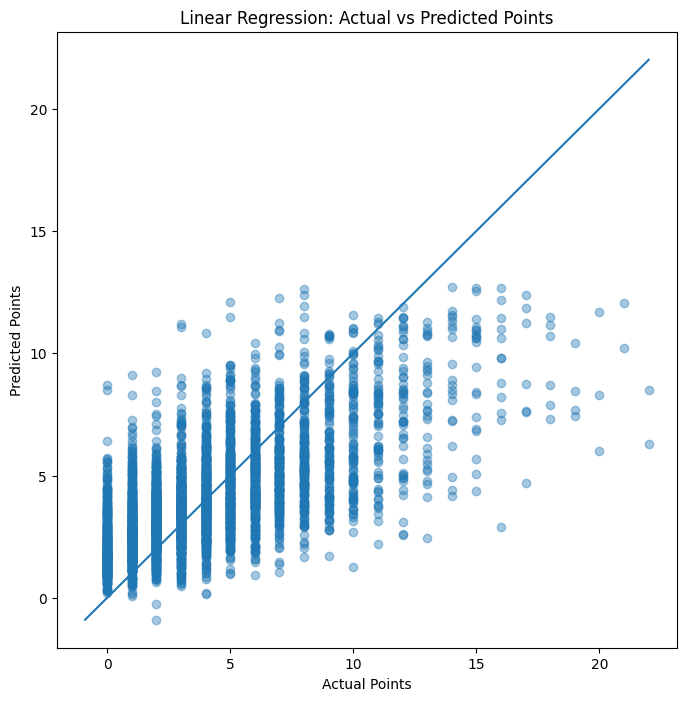

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))

plt.scatter(
    y_test,
    linear_predictions,
    alpha=0.4
)

# Perfect prediction line
min_val = min(y_test.min(), linear_predictions.min())
max_val = max(y_test.max(), linear_predictions.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val]
)

plt.xlabel("Actual Rebounds")
plt.ylabel("Predicted Rebounds")
plt.title("Linear Regression: Actual vs Predicted Rebounds")

plt.show()

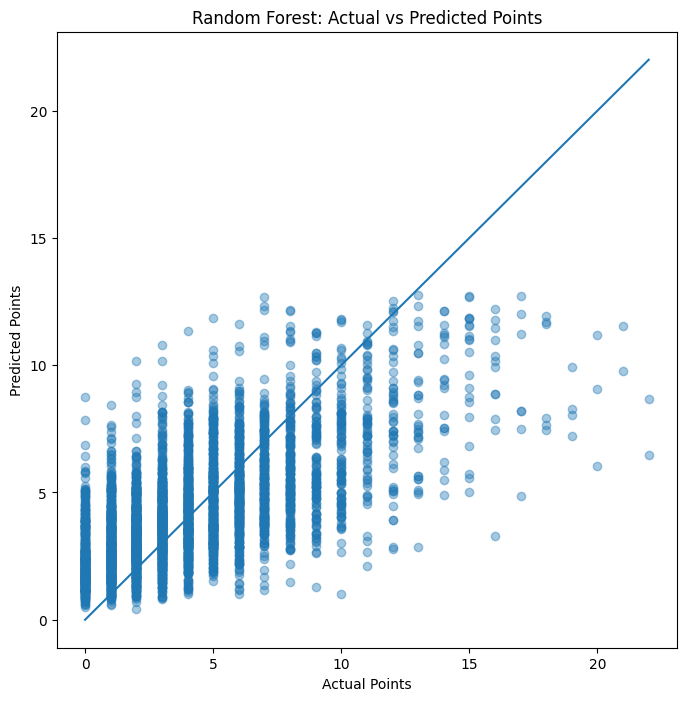

In [26]:
plt.figure(figsize=(8, 8))

plt.scatter(
    y_test,
    rf_predictions,
    alpha=0.4
)

min_val = min(y_test.min(), rf_predictions.min())
max_val = max(y_test.max(), rf_predictions.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val]
)

plt.xlabel("Actual Rebounds")
plt.ylabel("Predicted Rebounds")
plt.title("Random Forest: Actual vs Predicted Rebounds")

plt.show()

In [27]:
coefficients = pd.DataFrame({
    "Feature": features,
    "Coefficient": linear_model.coef_
}).sort_values("Coefficient", ascending=False)

print(coefficients)

             Feature  Coefficient
12    REB_SEASON_AVG     0.754529
44   FTA_STD_LAST_10     0.077099
17   AST_LAST_10_AVG     0.074590
22    MIN_LAST_5_AVG     0.068387
10    REB_LAST_5_AVG     0.061986
5    PTS_LAST_10_AVG     0.056293
19    AST_STD_LAST_5     0.053874
11   REB_LAST_10_AVG     0.047952
14   REB_STD_LAST_10     0.037827
34   FG3A_LAST_5_AVG     0.035270
38  FG3A_STD_LAST_10     0.033305
40    FTA_LAST_5_AVG     0.025837
15     AST_LAST_GAME     0.023055
21     MIN_LAST_GAME     0.021201
7     PTS_STD_LAST_5     0.020585
9      REB_LAST_GAME     0.018241
31    FGA_STD_LAST_5     0.013952
3      PTS_LAST_GAME     0.006099
6     PTS_SEASON_AVG     0.003506
30    FGA_SEASON_AVG     0.002469
2       GAMES_PLAYED    -0.000536
27     FGA_LAST_GAME    -0.001487
42    FTA_SEASON_AVG    -0.002784
39     FTA_LAST_GAME    -0.003658
4     PTS_LAST_5_AVG    -0.004109
32   FGA_STD_LAST_10    -0.004304
26   MIN_STD_LAST_10    -0.005093
25    MIN_STD_LAST_5    -0.008029
13    REB_STD_

In [28]:
coefficients = pd.DataFrame({
    "Feature": features,
    "Coefficient": linear_model.coef_
}).sort_values("Coefficient", ascending=False)

print(coefficients)

             Feature  Coefficient
12    REB_SEASON_AVG     0.754529
44   FTA_STD_LAST_10     0.077099
17   AST_LAST_10_AVG     0.074590
22    MIN_LAST_5_AVG     0.068387
10    REB_LAST_5_AVG     0.061986
5    PTS_LAST_10_AVG     0.056293
19    AST_STD_LAST_5     0.053874
11   REB_LAST_10_AVG     0.047952
14   REB_STD_LAST_10     0.037827
34   FG3A_LAST_5_AVG     0.035270
38  FG3A_STD_LAST_10     0.033305
40    FTA_LAST_5_AVG     0.025837
15     AST_LAST_GAME     0.023055
21     MIN_LAST_GAME     0.021201
7     PTS_STD_LAST_5     0.020585
9      REB_LAST_GAME     0.018241
31    FGA_STD_LAST_5     0.013952
3      PTS_LAST_GAME     0.006099
6     PTS_SEASON_AVG     0.003506
30    FGA_SEASON_AVG     0.002469
2       GAMES_PLAYED    -0.000536
27     FGA_LAST_GAME    -0.001487
42    FTA_SEASON_AVG    -0.002784
39     FTA_LAST_GAME    -0.003658
4     PTS_LAST_5_AVG    -0.004109
32   FGA_STD_LAST_10    -0.004304
26   MIN_STD_LAST_10    -0.005093
25    MIN_STD_LAST_5    -0.008029
13    REB_STD_

In [32]:
joblib.dump(linear_model, "../models/rebounds_model.pkl")

['../models/rebounds_model.pkl']